# Séance 4 (Notebook B) : Plus courts chemins : Dijkstra et A*

**Enseignant :** Jean Delpech

**Cours :** Algorithmie et développement dans l'ingénierie des données

**Classe :** M1 Data

**Année scolaire :** 2025/2026

**Dernière mise à jour :** juin 2026

## Objectifs

- Comprendre pourquoi BFS ne suffit pas sur un graphe pondéré
- Implémenter Dijkstra *from scratch* avec un min-heap (`heapq`) et analyser sa complexité
- Comprendre A* comme extension de Dijkstra guidée par une heuristique
- Savoir choisir entre BFS, Dijkstra et A* selon le contexte

## Plan

| # | Partie |
|---|---|
| 1 | Limites de BFS sur graphes pondérés |
| 2 | Dijkstra : algorithme et implémentation |
| 3 | Analyse de complexité et visualisation |
| 4 | A* : Dijkstra guidé par une heuristique |
| 5 | Comparaison BFS / Dijkstra / A* |

> **Notebooks de cette séance**
> - **Notebook A** : Graphes, BFS, DFS, Backtracking, DAG
> - **Notebook C** : PageRank et marche aléatoire sur graphe
> - Pour une présentation pas à pas de Dijkstra et A* plus ludique (et sans utiliser les heaps) vous pouvez consulter [mon cours « IA pour la programmation de jeux vidéos : Pathfinding »](https://github.com/Jehadel/IA-JV-cours/blob/main/Pathfinding.md) 

# Rappels : Classe Graph (Notebook A)

La cellule suivante redéfinit la classe `Graph` et les imports nécessaires pour que ce notebook
soit autonome. Elle est identique à celle du Notebook A.

In [1]:
# ── Imports et classe Graph (identique au Notebook A) ────────────────────────
from __future__ import annotations
from collections import defaultdict, deque
from typing import Optional
import heapq
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


class Graph:
    """
    Graphe générique représenté par une liste d'adjacence.
    Supporte les graphes orientés/non orientés, pondérés/non pondérés.
    """

    def __init__(self, directed: bool = False):
        self.directed = directed
        self._adj: dict[str, list[tuple[str, float]]] = defaultdict(list)
        self._vertices: set[str] = set()

    def add_vertex(self, u: str) -> None:
        self._vertices.add(u)
        if u not in self._adj:
            self._adj[u] = []

    def add_edge(self, u: str, v: str, weight: float = 1.0) -> None:
        self._vertices.update([u, v])
        self._adj[u].append((v, weight))
        if not self.directed:
            self._adj[v].append((u, weight))

    def neighbors(self, u: str) -> list[str]:
        return [v for v, _ in self._adj[u]]

    def neighbors_weighted(self, u: str) -> list[tuple[str, float]]:
        return list(self._adj[u])

    @property
    def vertices(self) -> set[str]:
        return set(self._vertices)

    @property
    def edges(self) -> list[tuple[str, str, float]]:
        result, seen = [], set()
        for u in self._adj:
            for v, w in self._adj[u]:
                key = (min(u, v), max(u, v)) if not self.directed else (u, v)
                if key not in seen:
                    result.append((u, v, w))
                    seen.add(key)
        return result

print("Classe Graph chargée.")

Classe Graph chargée.


# PARTIE 1 : Le cas des graphes pondérés

## 1.1 Rappel : BFS et distances non pondérées

Un parcours BFS garantit de trouver le plus court chemin en nombre d'arêtes dans un graphe non pondéré. Comme chaque arc a implicitement le même coût (1), BFS explore les sommets par distance croissante depuis la source. Le premier chemin trouvé vers un sommet est donc nécessairement le plus court en nombre d'arêtes. Minimiser le nombre d'arêtes revient à minimiser le coût total du trajet.

## 1.2 Le problème des poids

Dès que les arêtes ont des **poids différents**, BFS peut donner de mauvaises réponses. Un chemin passant par moins d'arêtes peut être plus coûteux qu'un chemin plus long.

```
Exemple :

    A ──1── B ──1── C
    │               │
    └──────10───────┘

BFS trouve A → C  (1 arête) mais le coût est 10, contre un coût de 2 en prenant 2 arrête A → B → C, donc il échout clairement à trouver le chemin le moins coûteux dans cette configuration.

si on avait :

    A ──10── B ──1── C
    │                │
    └────── 3 ───────┘

BFS trouve  A → C      (1 arête,  coût  3)  ← optimal, mais BFS l’a trouvé juste en comptant les arêtes, pas le coût !
alors que  A → B → C  (2 arêtes, coût 11) a un coût supérieur 

BFS peut trouver la bonne solution, mais juste parce que la configuration coïncinde avec un faible coût.
```

## 1.3 Dijkstra

Il nous faut un algorithme qui minimise la **somme des poids** sur le chemin, pas le nombre d'arêtes.
C'est exactement ce que fait **Dijkstra**.

In [5]:
# Démonstration : BFS vs réalité sur un graphe pondéré
from collections import deque

def bfs_unweighted(graph: Graph, source: str) -> dict[str, int]:
    """BFS standard : ignore les poids et compte uniquement les arêtes."""
    dist = {source: 0}
    queue = deque([source])

    while queue:
        u = queue.popleft()

        for v in graph.neighbors(u):
            if v not in dist:
                dist[v] = dist[u] + 1
                queue.append(v)

    return dist


# Graphe où BFS échoue
g = Graph(directed=True)

g.add_edge('A', 'B', weight=10)  # chemin direct mais coûteux
g.add_edge('A', 'C', weight=1)
g.add_edge('C', 'B', weight=1)   # chemin moins cher mais plus long

dist_bfs = bfs_unweighted(g, 'A')

print("Graphe :")
print("A --10-- B")
print(" \\")
print("  1")
print("   \\")
print("    C --1-- B")
print()

print(f"Nombre d’arêtes du plus court chemin selon BFS = {dist_bfs['B']} arête(s)")
print("→ BFS choisit le chemin direct A→B car il contient une seule arête (ce qui n’est pas le chemin le moins coûteux).")

Graphe :
A --10-- B
 \
  1
   \
    C --1-- B

Nombre d’arêtes du plus court chemin selon BFS = 1 arête(s)
→ BFS choisit le chemin direct A→B car il contient une seule arête (ce qui n’est pas le chemin le moins coûteux).


# PARTIE 2 : Algorithme de Dijkstra

## 2.1 Idée générale

On peut voir Dijkstra comme une généralisation de BFS aux graphes pondérés. Là où BFS explore les sommets par nombre croissant d'arêtes, Dijkstra les explore par coût croissant depuis la source.

Dijkstra maintient, pour chaque sommet, l'**estimation courante** du coût minimal pour l'atteindre depuis la source. Il raffine ces estimations en traitant toujours en priorité le sommet le moins cher à atteindre parmi ceux non encore finalisés. En d’autres termes, à chaque étape, il choisit le sommet dont le coût connu est le plus faible, puis vérifie si ce sommet permet d'améliorer le coût de ses voisins.

Prenons un exemple concret pour mieux comprendre : supposons que nous cherchions le chemin le moins coûteux depuis une ville de départ. Au fur et à mesure du parcours (exploration), nous connaissons progressivement le coût pour atteindre certaines villes, mais ces coûts peuvent encore être améliorés si l'on découvre un meilleur itinéraire.

À chaque étape, Dijkstra choisit la ville actuellement la moins coûteuse à atteindre, puis vérifie si passer par cette ville permet d'améliorer le coût des villes voisines.

L'outil central sera donc un **min-heap** (file de priorité à minimum) : on extrait toujours le sommet avec le coût courant le plus faible, on met à jour ses voisins, et on répète.

## 2.2 Exemple de résolution

Avant de présenter le pseudo code de l’algorithme dans le cas général, voici la résolution d’un exemple très simple.

Voici un graphe où :
- il y a un chemin direct mais coûteux
- un chemin indirect moins cher

Soient les arcs pondérés :

A → B : 4
A → C : 1
C → D : 2
B → D : 1

```
      4
   A ───► B
   │      │
 1 │      │ 1
   ▼      ▼
   C ───► D
      2
```


### Initialisation

Source : on part de A
On va considérer que les chemin non encore connus ont une distance infinie. Le chemin de A à A est connu : il vaut 0

| Sommet	| Distance |
|-----------|----------|
| A   |	0 |
|B |	∞ |
|C |	∞ |
|D |	∞ |

On met le premier chemin avec son coût associé dans le heap :
```
[(0,A)]
```

#### Étape 1 : extraction de A

À chaque étape on va extraire le sommet le moins coûteux.
A est le sommet le moins coûteux connu dans le heap. On l’extrait donc, puis on examine ses voisins et on calcule le coût associé :

A → B : 0 + 4 = 4
A → C : 0 + 1 = 1

Mise à jour :

| Sommet	| Distance |
|-----------|----------|
| A   |	0 |
|B |	4 |
|C |	1 |
|D |	∞ |

On met à jour le heap :

Une fois A extrait, on découvre ses voisins et on les insère dans la file de priorité avec leur coût depuis la source : C vaut 1 et B vaut 4, d’où le heap (1, C), (4, B).
```
[(1,C), (4,B)]
```

#### Étape 2 : extraction de C

C est maintenant le moins coûteux.

On examine :

C → D : 1 + 2 = 3

Mise à jour :

| Sommet	| Distance |
|-----------|----------|
| A   |	0 |
|B |	4 |
|C |	1 |
|D |	3 |

Heap :
```
[(3,D), (4,B)]
```

#### Étape 3 : extraction de D

D est devenu le sommet le moins coûteux dans le heap. Il n'a pas de voisin, les distances sont donc inchangées.

Heap :
```
[(4,B)]
```

#### Étape 4 : extraction de B

Il ne reste plus que B dans le heap. On examine :

B → D : 4 + 1 = 5

Or :

dist[D] = 3

Donc on n’apporte aucune amélioration.

Fin de l'algorithme.

Résultat

| Sommet	| Distance minimale depuis A|
|-----------|----------|
| A   |	0 |
|B |	4 |
|C |	1 |
|D |	3 |

On voit que le plus court chemin vers D a un coût de 3 (A → C → D).
> Note : pour retenir le chemin, il faut l’enregistrer au fur et à mesure qu’on explore

### Exercice 
Si vous voulez vous entraîner, essayez d’appliquer vous-même la procédure à ce graphe :
      5
   A ───► B
   │
 2 │
   ▼
   C ───► B
      1

Indication :

- A découvre d'abord B avec un coût de 5
- puis, en passant par C, découvre un meilleur coût de 3

## 2.3 Algorithme pas à pas

```
Dijkstra(graphe G, source s) :

    dist[s] = 0,  dist[v] = ∞  pour tout v ≠ s
    parent[v] = None  pour tout v
    heap = [(0, s)]          ← min-heap : (coût, sommet)

    tant que heap non vide :
        (d, u) ← extraire le minimum du heap
        si d > dist[u] : ignorer  ← entrée obsolète (lazy deletion)

        pour chaque voisin v de u avec poids w :
            si dist[u] + w < dist[v] :
                dist[v]   = dist[u] + w    ← relaxation
                parent[v] = u ← on enregistre le chemin pris
                heappush(heap, (dist[v], v))
```

> Relaxation : opération qui consiste à vérifier si un chemin passant par un sommet intermédiaire permet d'atteindre un voisin à un coût inférieur à celui connu jusqu'à présent. Si c'est le cas, on met à jour ce coût.
> 
> Lazy deletion : technique utilisée avec une file de priorité où l’on ne met pas à jour ou ne supprime pas immédiatement les anciennes entrées devenues obsolètes ; on les laisse dans le heap et on les ignore simplement lorsqu’elles sont extraites si elles ne correspondent plus à la meilleure distance connue.
>
> Pour une implémentation sans heap et une description pas à pas, voyez mon cours sur le [pathfinding](https://github.com/Jehadel/IA-JV-cours/blob/main/Pathfinding.md) dans les jeux vidéos (déjà mentionné en tête de document)

### Points clés

- **Relaxation** : mettre à jour `dist[v]` si on a trouvé un chemin moins cher vers v via u.
- **Lazy deletion** : `heapq` en Python ne supporte pas la mise à jour d'une entrée existante.
  On pousse simplement une nouvelle entrée `(nouveau_coût, v)` et on ignore les entrées obsolètes quand on les extrait (`if d > dist[u]: continue`). On implémente ci-dessous « un Dijkstra » pas à pas pour montrer le mécanisme.
- **Terminaison** : quand on extrait u du heap, `dist[u]` est définitif, on ne trouvera pas de chemin moins cher vers u par la suite (valable uniquement si tous les poids sont **≥ 0**)
- **Enregistrer le chemin** : on crée un dictionnaire pour pouvoir reconstruire le chemin (stricto sensu l’algorithme ne stocke que le coût des chemins les moins coûteux entre chaque sommets). On revient sur ce point ci-dessous après l’implémentation de l’algorithme pour aérer cet exposé

### Complexité

En pratique, `heapq` est toujours utilisé en Python (il y a d’autre implémentation possible de heap). La complexité associée est **O((V + E) log V)**
> Rappel : V = vertices (sommets) et E = edges (arêtes)
> 
> **Limitation fondamentale :** Dijkstra ne fonctionne pas avec des **poids négatifs**.
> Pour des poids négatifs, utiliser Bellman-Ford (O(VE), hors programme).

# PARTIE 3 : Analyse de complexité et visualisation

## 3.1 Pourquoi O((V + E) log V) ?

Chaque sommet est extrait du heap **au plus une fois** (grâce à la lazy deletion).
Chaque extraction coûte O(log V) (réorganisation du heap de taille V).
Chaque arête peut déclencher au plus un `heappush`, chaque push coûte O(log V).

Au total : **V extractions × O(log V) + E insertions × O(log V) = O((V + E) log V)**.

## 3.2 Comparaison avec BFS

| | BFS | Dijkstra |
|---|---|---|
| Graphe cible | Non pondéré (ou poids = 1) | Pondéré, poids ≥ 0 |
| Structure | File FIFO (`deque`) | Min-heap (`heapq`) |
| Complexité | O(V + E) | O((V + E) log V) |
| Optimalité | Oui (nb d'arêtes) | Oui (somme des poids) |

## 3.3 Implémentation

In [6]:
def dijkstra(
    graph: Graph,
    source: str
) -> tuple[dict[str, float], dict[str, Optional[str]]]:
    """
    Algorithme de Dijkstra avec min-heap (heapq).

    Parameters
    ----------
    graph  : Graph   graphe orienté ou non, pondéré, poids >= 0
    source : str     sommet de départ

    Returns
    -------
    dist   : dict sommet → coût minimal depuis source (inf si non atteignable)
    parent : dict sommet → prédécesseur sur le chemin optimal (None pour source)
    """
    # Initialisation : tous les sommets à l'infini
    dist: dict[str, float]          = {v: float('inf') for v in graph.vertices}
    parent: dict[str, Optional[str]] = {v: None for v in graph.vertices}
    dist[source] = 0

    # Min-heap : (coût_courant, sommet)
    heap: list[tuple[float, str]] = [(0.0, source)]

    while heap:
        d, u = heapq.heappop(heap)         # extraire le sommet le moins cher

        # Lazy deletion : ignorer les entrées obsolètes
        if d > dist[u]:
            continue

        # Relaxation des voisins
        for v, w in graph.neighbors_weighted(u):
            new_dist = dist[u] + w
            if new_dist < dist[v]:
                dist[v]   = new_dist
                parent[v] = u
                heapq.heappush(heap, (new_dist, v))

    return dist, parent


def reconstruct_path(parent: dict[str, Optional[str]], source: str, target: str) -> Optional[list[str]]:
    """Reconstruit le chemin optimal de source à target depuis le dict parent."""
    if parent.get(target) is None and target != source:
        return None  # non atteignable
    path, current = [], target
    while current is not None:
        path.append(current)
        current = parent[current]
    return list(reversed(path))


# ── Démonstration ──────────────────────────────────────────────────
g = Graph(directed=False)
for u, v, w in [
    ('A', 'B', 4), ('A', 'C', 2),
    ('B', 'C', 1), ('B', 'D', 5),
    ('C', 'D', 8), ('C', 'E', 10),
    ('D', 'E', 2), ('D', 'F', 6),
    ('E', 'F', 3),
]:
    g.add_edge(u, v, w)

dist, parent = dijkstra(g, 'A')

print("=== Dijkstra depuis A ===\n")
print("Distances minimales :")
for v in sorted(dist):
    path = reconstruct_path(parent, 'A', v)
    path_str = ' → '.join(path) if path else '?'
    print(f"  A → {v} : coût {dist[v]:5.1f}   chemin : {path_str}")

=== Dijkstra depuis A ===

Distances minimales :
  A → A : coût   0.0   chemin : A
  A → B : coût   3.0   chemin : A → C → B
  A → C : coût   2.0   chemin : A → C
  A → D : coût   8.0   chemin : A → C → B → D
  A → E : coût  10.0   chemin : A → C → B → D → E
  A → F : coût  13.0   chemin : A → C → B → D → E → F


### Reconstruire le chemin

L'algorithme tel que décrit jusqu'ici calcule le coût minimal pour atteindre chaque sommet, mais pas le chemin lui-même. À la fin, on sait que le chemin le moins coûteux de A vers F coûte 13, mais on ne sait pas par quels sommets il passe.

Pour reconstruire le chemin, on maintient en parallèle un dictionnaire parent : à chaque fois qu'on relaxe une arête (c'est-à-dire qu'on trouve un meilleur chemin vers v via u), on enregistre `parent[v] = u`. Ce dictionnaire mémorise, pour chaque sommet, par quel sommet on est arrivé de façon optimale.

Relaxation de v via u :
```
    si dist[u] + w < dist[v] :
        dist[v]   = dist[u] + w
        parent[v] = u          ← on mémorise le prédécesseur
```
Une fois Dijkstra terminé, on reconstruit le chemin en remontant la chaîne des prédécesseurs depuis la cible jusqu'à la source :

```
chemin = []
current = cible
tant que current n'est pas None :
    chemin.append(current)
    current = parent[current]
inverser chemin → [source, ..., cible]
```

C'est le même principe que la reconstruction de chemin après BFS (Notebook A) : dans les deux cas, on remonte le dictionnaire parent de la cible vers la source, puis on inverse.

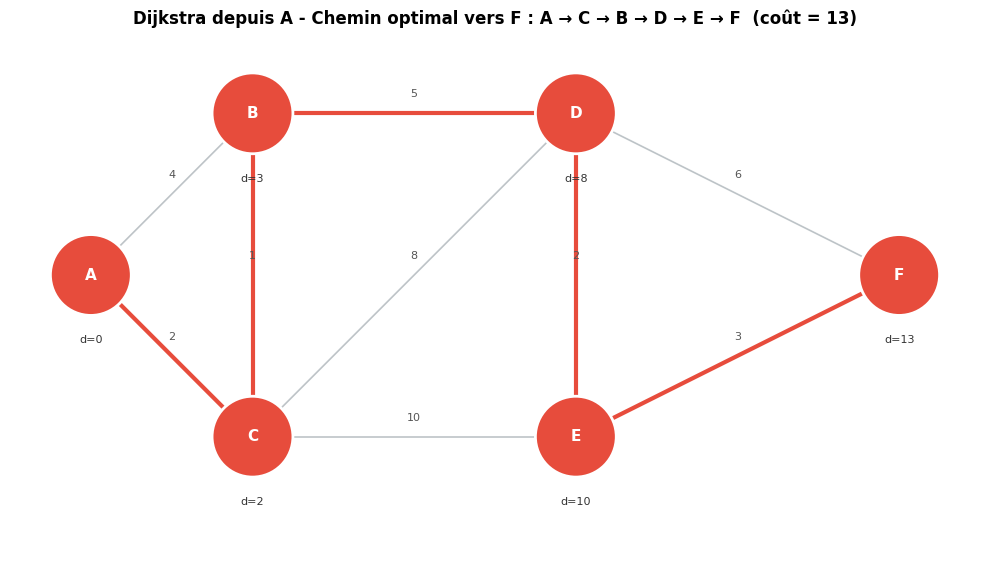

In [7]:
# Visualisation du graphe avec les distances et le chemin optimal
def plot_dijkstra(graph: Graph, dist: dict, parent: dict,
                 source: str, target: str, positions: dict):
    """Affiche le graphe, colore le chemin optimal source→target."""
    path = reconstruct_path(parent, source, target)
    path_edges = set(zip(path, path[1:])) if path else set()

    fig, ax = plt.subplots(figsize=(10, 6))

    # Arêtes
    for u, v, w in graph.edges:
        x1, y1 = positions[u]; x2, y2 = positions[v]
        is_path = (u, v) in path_edges or (v, u) in path_edges
        color  = '#e74c3c' if is_path else '#bdc3c7'
        lw     = 3.0       if is_path else 1.2
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=lw, zorder=1)
        # Poids
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx, my + 0.12, str(w), ha='center', va='center',
                fontsize=8, color='#555', zorder=3)

    # Sommets
    for v, (x, y) in positions.items():
        on_path = path and v in path
        facecolor = '#e74c3c' if on_path else '#3498db'
        ax.add_patch(plt.Circle((x, y), 0.25, color=facecolor, zorder=4, ec='white', lw=2))
        ax.text(x, y, v, ha='center', va='center',
                fontweight='bold', fontsize=11, color='white', zorder=5)
        # Distance minimale
        d_str = f"{dist[v]:.0f}" if dist[v] != float('inf') else '∞'
        ax.text(x, y - 0.42, f"d={d_str}", ha='center', fontsize=8, color='#333', zorder=5)

    ax.set_xlim(-0.5, 5.5); ax.set_ylim(-0.8, 2.5)
    ax.set_aspect('equal'); ax.axis('off')
    path_str = ' → '.join(path) if path else '?'
    ax.set_title(
        f"Dijkstra depuis {source} - Chemin optimal vers {target} : {path_str}  "
        f"(coût = {dist[target]:.0f})",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


positions = {
    'A': (0, 1), 'B': (1, 2), 'C': (1, 0),
    'D': (3, 2), 'E': (3, 0), 'F': (5, 1),
}

plot_dijkstra(g, dist, parent, source='A', target='F', positions=positions)

### Suivi du lazy deletion

In [8]:
# Trace pas à pas de Dijkstra pour illustrer la lazy deletion
def dijkstra_verbose(graph: Graph, source: str) -> None:
    """Dijkstra avec affichage de chaque étape - pédagogique uniquement."""
    dist   = {v: float('inf') for v in graph.vertices}
    parent = {v: None for v in graph.vertices}
    dist[source] = 0
    heap  = [(0.0, source)]
    finalized: set[str] = set()
    step = 0

    print(f"{'Étape':>5}  {'Extrait':>8}  {'dist[u]':>8}  {'Action'}")
    print("-" * 60)

    while heap:
        d, u = heapq.heappop(heap)
        step += 1

        if d > dist[u]:
            print(f"{step:5d}  {u:>8}  {d:>8.1f}  ← obsolète (lazy deletion), ignoré")
            continue

        finalized.add(u)
        print(f"{step:5d}  {u:>8}  {d:>8.1f}  finalisé - relaxation des voisins :")

        for v, w in graph.neighbors_weighted(u):
            new_dist = dist[u] + w
            if new_dist < dist[v]:
                old = dist[v]
                dist[v]   = new_dist
                parent[v] = u
                heapq.heappush(heap, (new_dist, v))
                print(f"{'':20s}  {v}: {old:.0f} → {new_dist:.0f}  (via {u}, +{w})")

    print()
    print("Distances finales :", {v: f"{d:.0f}" for v, d in sorted(dist.items())})


dijkstra_verbose(g, 'A')

Étape   Extrait   dist[u]  Action
------------------------------------------------------------
    1         A       0.0  finalisé - relaxation des voisins :
                      B: inf → 4  (via A, +4)
                      C: inf → 2  (via A, +2)
    2         C       2.0  finalisé - relaxation des voisins :
                      B: 4 → 3  (via C, +1)
                      D: inf → 10  (via C, +8)
                      E: inf → 12  (via C, +10)
    3         B       3.0  finalisé - relaxation des voisins :
                      D: 10 → 8  (via B, +5)
    4         B       4.0  ← obsolète (lazy deletion), ignoré
    5         D       8.0  finalisé - relaxation des voisins :
                      E: 12 → 10  (via D, +2)
                      F: inf → 14  (via D, +6)
    6         D      10.0  ← obsolète (lazy deletion), ignoré
    7         E      10.0  finalisé - relaxation des voisins :
                      F: 14 → 13  (via E, +3)
    8         E      12.0  ← obsolète (lazy deletio

# PARTIE 4 : A* : Dijkstra guidé par une heuristique

## 4.1 Motivation

Dijkstra explore les sommets dans l'ordre de leur distance depuis la **source**. Il ne sait pas dans quelle direction se trouve la **destination**, il explore donc potentiellement dans toutes les directions, y compris loin de la cible. Il explore de manière exhaustive tous les chemins possibles et sélectionne les moins coûteux.

**A*** corrige cela en ajoutant une **heuristique** h(v) : une estimation du coût restant pour aller de v à la destination. 

> Une heuristique est une stratégie qui permet de nous orienter vers une solution dont on ne peut garantir qu’elle est la meilleure, mais au moins « suffisamment bonne »
>
> Ici, on  entend plus spécifiqueemnt par heuristique une méthode ou une fonction qui guide la recherche en fournissant une estimation du coût ou de la distance restante vers un objectif, sans garantir qu’elle conduit directement à la solution optimale, mais en permettant d’orienter efficacement l’exploration.

À chaque étape, A* extrait le sommet qui minimise :

```
f(v) = g(v) + h(v)
       ↑         ↑
  coût réel   estimation
  depuis s    vers cible
              (coût de l’heuristique, d’où « h »)
```

## 4.2 Condition d'admissibilité

L'heuristique doit être **admissible** : elle ne doit **jamais surestimer** le coût réel.

```
h(v) ≤ coût_réel(v → cible)   pour tout sommet v
```

Si cette condition est respectée, A* trouve toujours le chemin optimal.

**Exemples d'heuristiques admissibles :**
- Distance euclidienne entre v et la cible (pour un graphe géométrique)
- Distance de Manhattan (pour une grille)
- Distance de Haversine (pour un réseau routier avec coordonnées GPS)

Si h(v) = 0 pour tout v → A* se réduit exactement à **Dijkstra**.

> Encore une fois je renvoie vers mon cours « [Pathfinding](https://github.com/Jehadel/IA-JV-cours/blob/main/Pathfinding.md) » dans le jeux vidéo pour une présentation pas-à-pas et contextualisée (et sans faire appel au heap).

## 4.3 Algorithme

```
A*(graphe G, source s, cible t, heuristique h) :

    g[s] = 0,  g[v] = ∞  pour tout v ≠ s
    heap = [(h(s), 0, s)]    ← (f = g + h, g, sommet)

    tant que heap non vide :
        (f, g_u, u) ← extraire le minimum
        si g_u > g[u] : ignorer  ← lazy deletion
        si u == t : chemin trouvé → reconstruire

        pour chaque voisin v de u avec poids w :
            new_g = g[u] + w
            si new_g < g[v] :
                g[v]     = new_g
                parent[v] = u
                heappush(heap, (new_g + h(v), new_g, v))
```

> La seule différence avec Dijkstra : on trie par `g + h` au lieu de `g` seul.

### Implémentation

On choisit ici la [distance de Manhattan](https://fr.wikipedia.org/wiki/Distance_de_Manhattan) (comme si on ne se déplaçait qu’à « angle droit ») comme heuristique.

In [9]:
def astar(
    graph: Graph,
    source: str,
    target: str,
    heuristic: dict[str, float]
) -> tuple[Optional[float], Optional[list[str]], int]:
    """
    Algorithme A* avec heuristique fournie sous forme de dictionnaire.

    Parameters
    ----------
    graph     : Graph
    source    : str
    target    : str
    heuristic : dict sommet → estimation du coût restant vers target

    Returns
    -------
    cost      : coût optimal (None si non atteignable)
    path      : chemin optimal
    explored  : nombre de sommets extraits du heap (mesure d'efficacité)
    """
    g_cost: dict[str, float]          = {v: float('inf') for v in graph.vertices}
    parent: dict[str, Optional[str]]  = {v: None         for v in graph.vertices}
    g_cost[source] = 0

    h = heuristic
    heap: list[tuple[float, float, str]] = [(h[source], 0.0, source)]
    explored = 0

    while heap:
        f, g_u, u = heapq.heappop(heap)

        if g_u > g_cost[u]:
            continue  # entrée obsolète

        explored += 1

        if u == target:
            path = []
            cur = target
            while cur is not None:
                path.append(cur)
                cur = parent[cur]
            return g_cost[target], list(reversed(path)), explored

        for v, w in graph.neighbors_weighted(u):
            new_g = g_cost[u] + w
            if new_g < g_cost[v]:
                g_cost[v] = new_g
                parent[v] = u
                heapq.heappush(heap, (new_g + h[v], new_g, v))

    return None, None, explored


# ── Démonstration sur une grille 4×4 ──────────────────────────────
# Chaque nœud est une case (row, col), les arcs relient les cases adjacentes
# avec des poids variables (terrain). On cherche le chemin de (0,0) à (3,3).

def make_grid_graph(n: int, weights: dict) -> Graph:
    """Crée un graphe de grille n×n avec des poids par arête."""
    g = Graph(directed=False)
    for r in range(n):
        for c in range(n):
            node = f"{r},{c}"
            for dr, dc in [(0,1),(1,0),(0,-1),(-1,0)]:
                nr, nc = r + dr, c + dc
                if 0 <= nr < n and 0 <= nc < n:
                    neighbor = f"{nr},{nc}"
                    w = weights.get((node, neighbor), weights.get((neighbor, node), 1))
                    g.add_edge(node, neighbor, w)
    return g

# Poids (certaines cases ont un terrain difficile = coût élevé)
N = 4
custom_weights = {
    ('0,1', '0,2'): 5, ('1,1', '1,2'): 5, ('2,1', '2,2'): 5,
    ('0,2', '0,3'): 5, ('1,2', '1,3'): 5,
}
grid = make_grid_graph(N, custom_weights)

source, target = '0,0', '3,3'

# Heuristique : distance de Manhattan vers la cible
def manhattan(node: str, goal: str) -> float:
    r1, c1 = map(int, node.split(','))
    r2, c2 = map(int, goal.split(','))
    return abs(r1 - r2) + abs(c1 - c2)

h_astar    = {v: manhattan(v, target) for v in grid.vertices}
h_dijkstra = {v: 0.0                  for v in grid.vertices}  # h=0 → Dijkstra

cost_astar,    path_astar,    exp_astar    = astar(grid, source, target, h_astar)
cost_dijkstra, path_dijkstra, exp_dijkstra = astar(grid, source, target, h_dijkstra)

print(f"Source : {source}   Cible : {target}\n")
print(f"Dijkstra (h=0)    : coût {cost_dijkstra:.0f}, chemin {' → '.join(path_dijkstra)}")
print(f"                    sommets explorés : {exp_dijkstra}")
print()
print(f"A* (Manhattan)    : coût {cost_astar:.0f}, chemin {' → '.join(path_astar)}")
print(f"                    sommets explorés : {exp_astar}")
print()
print("A* explore moins de sommets car il est guidé vers la cible.")

Source : 0,0   Cible : 3,3

Dijkstra (h=0)    : coût 6, chemin 0,0 → 0,1 → 1,1 → 2,1 → 3,1 → 3,2 → 3,3
                    sommets explorés : 12

A* (Manhattan)    : coût 6, chemin 0,0 → 0,1 → 1,1 → 2,1 → 3,1 → 3,2 → 3,3
                    sommets explorés : 10

A* explore moins de sommets car il est guidé vers la cible.


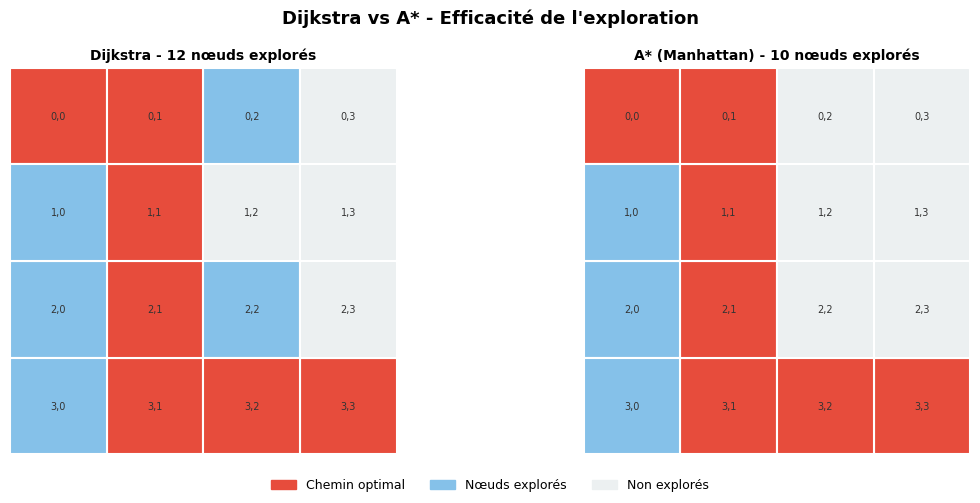

In [10]:
# Visualisation côte à côte Dijkstra vs A* sur la grille
def plot_grid_search(grid: Graph, path: list[str], explored_nodes: set[str],
                     n: int, title: str, ax):
    """Affiche la grille avec le chemin et les nœuds explorés."""
    path_set = set(path)
    for node in grid.vertices:
        r, c = map(int, node.split(','))
        if node in path_set:
            color = '#e74c3c'
        elif node in explored_nodes:
            color = '#85c1e9'
        else:
            color = '#ecf0f1'
        ax.add_patch(plt.Rectangle((c, n-1-r), 1, 1, fc=color, ec='white', lw=1.5))
        ax.text(c + 0.5, n - 0.5 - r, node, ha='center', va='center', fontsize=7, color='#333')

    ax.set_xlim(0, n); ax.set_ylim(0, n)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=10, fontweight='bold')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# On relance en collectant les nœuds explorés
def astar_tracked(graph, source, target, heuristic):
    g_cost = {v: float('inf') for v in graph.vertices}
    parent = {v: None for v in graph.vertices}
    g_cost[source] = 0
    heap = [(heuristic[source], 0.0, source)]
    explored = []
    while heap:
        f, g_u, u = heapq.heappop(heap)
        if g_u > g_cost[u]:
            continue
        explored.append(u)
        if u == target:
            path, cur = [], target
            while cur is not None:
                path.append(cur); cur = parent[cur]
            return list(reversed(path)), explored
        for v, w in graph.neighbors_weighted(u):
            new_g = g_cost[u] + w
            if new_g < g_cost[v]:
                g_cost[v] = new_g; parent[v] = u
                heapq.heappush(heap, (new_g + heuristic[v], new_g, v))
    return None, explored

path_d, exp_d = astar_tracked(grid, source, target, h_dijkstra)
path_a, exp_a = astar_tracked(grid, source, target, h_astar)

plot_grid_search(grid, path_d, set(exp_d), N,
                 f"Dijkstra - {len(exp_d)} nœuds explorés", axes[0])
plot_grid_search(grid, path_a, set(exp_a), N,
                 f"A* (Manhattan) - {len(exp_a)} nœuds explorés", axes[1])

# Légende
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Chemin optimal'),
    mpatches.Patch(color='#85c1e9', label='Nœuds explorés'),
    mpatches.Patch(color='#ecf0f1', label='Non explorés'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=9, frameon=False)
fig.suptitle("Dijkstra vs A* - Efficacité de l'exploration", fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [ ]:
# Réseau routier simplifié (distances en km, approximatives)
cities = Graph(directed=False)
roads = [
    ('Paris',    'Reims',      145),
    ('Paris',    'Orleans',    120),
    ('Paris',    'Rouen',      135),
    ('Reims',    'Metz',       190),
    ('Reims',    'Dijon',      280),
    ('Orleans',  'Dijon',      295),
    ('Orleans',  'Tours',       115),
    ('Tours',    'Bordeaux',   340),
    ('Tours',    'Nantes',     190),
    ('Bordeaux', 'Toulouse',   245),
    ('Bordeaux', 'Nantes',     335),
    ('Toulouse', 'Montpellier',245),
    ('Toulouse', 'Lyon',       475),
    ('Montpellier','Lyon',     305),
    ('Montpellier','Marseille', 170),
    ('Lyon',     'Dijon',      190),
    ('Lyon',     'Marseille',  315),
    ('Lyon',     'Grenoble',   110),
    ('Metz',     'Dijon',      270),
    ('Grenoble', 'Marseille',  305),
]
for u, v, w in roads:
    cities.add_edge(u, v, w)

# Coordonnées approximatives (longitude, latitude) pour l'heuristique
coords = {
    'Paris':       (2.35,  48.85),
    'Reims':       (4.03,  49.25),
    'Metz':        (6.18,  49.12),
    'Rouen':       (1.10,  49.44),
    'Orleans':     (1.91,  47.90),
    'Dijon':       (5.04,  47.32),
    'Tours':       (0.69,  47.39),
    'Nantes':      (-1.55, 47.22),
    'Bordeaux':    (-0.58, 44.84),
    'Toulouse':    (1.44,  43.60),
    'Montpellier': (3.88,  43.61),
    'Lyon':        (4.83,  45.75),
    'Marseille':   (5.37,  43.30),
    'Grenoble':    (5.72,  45.19),
}

# Heuristique : distance euclidienne approchée en km (1° ≈ 111 km)
def euclidean_km(a: str, b: str) -> float:
    lon1, lat1 = coords[a]; lon2, lat2 = coords[b]
    return math.sqrt(((lon2 - lon1) * 111 * math.cos(math.radians((lat1+lat2)/2)))**2
                     + ((lat2 - lat1) * 111)**2)

source, target = 'Paris', 'Marseille'

# Dijkstra
dist_d, parent_d = dijkstra(cities, source)
path_d = reconstruct_path(parent_d, source, target)

# A* avec heuristique euclidienne
h = {v: euclidean_km(v, target) for v in cities.vertices}
cost_a, path_a, exp_a = astar(cities, source, target, h)
_, _, exp_d = astar(cities, source, target, {v: 0.0 for v in cities.vertices})

print(f"=== {source} → {target} ===\n")
print(f"Dijkstra : coût {dist_d[target]:.0f} km")
print(f"  chemin : {' → '.join(path_d)}")
print(f"  sommets explorés : {exp_d}")
print()
print(f"A* (euclidien) : coût {cost_a:.0f} km")
print(f"  chemin : {' → '.join(path_a)}")
print(f"  sommets explorés : {exp_a}")

# PARTIE 5 : Exercice : réseau de villes

## Contexte

On modélise un réseau routier simplifié entre villes françaises. Les poids représentent
les distances routières approximatives en kilomètres. On cherche le chemin le moins coûteux
entre deux villes.

## Tâche

1. Construire le graphe du réseau ci-dessous (exécuter la cellule)
2. Appliquer Dijkstra pour trouver le plus court chemin entre deux villes données
3. Définir une heuristique à vol d'oiseau (distance euclidienne approchée) et appliquer A*
4. Comparer le nombre de sommets explorés par les deux algorithmes

In [13]:
# ── Réseau routier simplifié (distances en km, approximatives) ────
cities = Graph(directed=False)
roads = [
    ('Paris',       'Reims',        145),
    ('Paris',       'Orleans',      120),
    ('Paris',       'Rouen',        135),
    ('Reims',       'Metz',         190),
    ('Reims',       'Dijon',        280),
    ('Orleans',     'Dijon',        295),
    ('Orleans',     'Tours',        115),
    ('Tours',       'Bordeaux',     340),
    ('Tours',       'Nantes',       190),
    ('Bordeaux',    'Toulouse',     245),
    ('Bordeaux',    'Nantes',       335),
    ('Toulouse',    'Montpellier',  245),
    ('Toulouse',    'Lyon',         475),
    ('Montpellier', 'Lyon',         305),
    ('Montpellier', 'Marseille',    170),
    ('Lyon',        'Dijon',        190),
    ('Lyon',        'Marseille',    315),
    ('Lyon',        'Grenoble',     110),
    ('Metz',        'Dijon',        270),
    ('Grenoble',    'Marseille',    305),
]
for u, v, w in roads:
    cities.add_edge(u, v, w)

# Coordonnées approximatives (longitude, latitude) pour l'heuristique A*
coords = {
    'Paris':        ( 2.35,  48.85),
    'Reims':        ( 4.03,  49.25),
    'Metz':         ( 6.18,  49.12),
    'Rouen':        ( 1.10,  49.44),
    'Orleans':      ( 1.91,  47.90),
    'Dijon':        ( 5.04,  47.32),
    'Tours':        ( 0.69,  47.39),
    'Nantes':       (-1.55,  47.22),
    'Bordeaux':     (-0.58,  44.84),
    'Toulouse':     ( 1.44,  43.60),
    'Montpellier':  ( 3.88,  43.61),
    'Lyon':         ( 4.83,  45.75),
    'Marseille':    ( 5.37,  43.30),
    'Grenoble':     ( 5.72,  45.19),
}

print(f"Graphe chargé : {len(cities.vertices)} villes, {len(cities.edges)} routes.")
print(f"Villes disponibles : {sorted(cities.vertices)}")

Graphe chargé : 14 villes, 20 routes.
Villes disponibles : ['Bordeaux', 'Dijon', 'Grenoble', 'Lyon', 'Marseille', 'Metz', 'Montpellier', 'Nantes', 'Orleans', 'Paris', 'Reims', 'Rouen', 'Toulouse', 'Tours']


In [ ]:
# EXERCICE : à vous de jouer !

# ── Paramètres ────────────────────────────────────────────────────
source = 'Paris'
target = 'Marseille'

# ── TODO 1 : Appliquer Dijkstra ───────────────────────────────────
# Utilisez la fonction dijkstra() définie en partie 2.
# Elle retourne (dist, parent) où :
#   dist[v]   = coût minimal pour atteindre v depuis source
#   parent[v] = prédécesseur de v sur le chemin optimal

dist_d, parent_d = ...   # TODO

# ── TODO 2 : Reconstruire le chemin optimal ───────────────────────
# Utilisez reconstruct_path() définie en partie 2.
# Elle prend (parent, source, target) et retourne la liste des villes
# dans l'ordre, de source à target.

path_d = ...   # TODO

# ── Affichage des résultats ───────────────────────────────────────
print(f"Chemin Dijkstra ({source} → {target}) :")
print(f"  {' → '.join(path_d)}")
print(f"  Coût total : {dist_d[target]:.0f} km")

# ── TODO 3 (bonus) : Appliquer A* avec heuristique euclidienne ────
# Définissez h[v] = distance euclidienne approchée en km entre v et target.
# Rappel : 1 degré ≈ 111 km. Attention à corriger la longitude
# par cos(latitude moyenne) pour tenir compte de la courbure terrestre.
# Utilisez ensuite astar() définie en partie 4.

def euclidean_km(a: str, b: str) -> float:
    lon1, lat1 = coords[a]
    lon2, lat2 = coords[b]
    # TODO : calculer et retourner la distance approchée en km
    ...

h = ...   # TODO : dict {ville: euclidean_km(ville, target) pour chaque ville}

cost_a, path_a, exp_a = ...   # TODO : appel astar()
_, _, exp_d = astar(cities, source, target, {v: 0.0 for v in cities.vertices})

print(f"\nComparaison Dijkstra vs A* ({source} → {target}) :")
print(f"  Dijkstra : {exp_d} sommets explorés, coût {dist_d[target]:.0f} km")
print(f"  A*       : {exp_a} sommets explorés, coût {cost_a:.0f} km")
print(f"  Chemin A* : {' → '.join(path_a)}")

# ── Visualisation ─────────────────────────────────────────────────
def plot_city_graph(graph, coords, path, source, target, title):
    path_edges = set(zip(path, path[1:])) if path else set()
    path_set   = set(path)

    lons = [c[0] for c in coords.values()]
    lats = [c[1] for c in coords.values()]
    lon_min, lon_max = min(lons), max(lons)
    lat_min, lat_max = min(lats), max(lats)

    def norm(lon, lat):
        x = (lon - lon_min) / (lon_max - lon_min) * 10
        y = (lat - lat_min) / (lat_max - lat_min) * 7
        return x, y

    fig, ax = plt.subplots(figsize=(12, 8))

    for u, v, w in graph.edges:
        x1, y1 = norm(*coords[u]); x2, y2 = norm(*coords[v])
        is_path = (u, v) in path_edges or (v, u) in path_edges
        ax.plot([x1, x2], [y1, y2],
                color='#e74c3c' if is_path else '#bdc3c7',
                linewidth=3 if is_path else 1, zorder=1, alpha=0.8)
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx, my + 0.15, f"{w:.0f}", ha='center',
                fontsize=6.5, color='#888', zorder=2)

    for city, (lon, lat) in coords.items():
        x, y = norm(lon, lat)
        color  = '#e74c3c' if city in path_set else '#3498db'
        marker = '*' if city in (source, target) else 'o'
        size   = 180 if city in (source, target) else 80
        ax.scatter(x, y, c=color, s=size, zorder=4, marker=marker,
                   edgecolors='white', linewidths=1.5)
        offset_y = 0.28 if city not in ('Montpellier', 'Grenoble') else -0.35
        ax.text(x, y + offset_y, city, ha='center', fontsize=8,
                fontweight='bold' if city in path_set else 'normal',
                color='#222', zorder=5)

    ax.set_xlim(-0.5, 10.8); ax.set_ylim(-0.5, 7.8)
    ax.axis('off')
    ax.set_title(f"{title}\n{' → '.join(path)}  (coût = {dist_d[target]:.0f} km)",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_city_graph(cities, coords, path_d, source, target,
                f"Dijkstra — Plus court chemin {source} → {target}")

# Conclusion

## Réflexes à développer

> **Poids tous égaux à 1 (ou graphe non pondéré) ?** → BFS, O(V+E), optimal et simple.

> **Poids positifs quelconques, source unique ?** → Dijkstra avec `heapq`.

> **Poids positifs, cible connue, heuristique disponible ?** → A*, explore moins de sommets que Dijkstra.

> **Poids négatifs ?** → Dijkstra ne fonctionne pas → Bellman-Ford (O(VE), hors programme).

## Lazy deletion

Le pattern `if d > dist[u]: continue` est fondamental : `heapq` en Python ne permet pas
de mettre à jour une entrée existante. On empile de nouvelles entrées et on ignore les
obsolètes à l'extraction. C'est un idiome Python à connaître.

## Pour aller plus loin : Mini-mémoires

*Ces éléments ne sont pas traités en cours. Ils constituent des pistes d'approfondissement.*

- **`A*` complet avec heuristique Haversine** sur un réseau routier réel (OSMnx) et visualisation Folium
- **Comparaison Dijkstra vs `A*`** : nombre de nœuds explorés sur un réseau géospatial réel
- **KD-trees et structures ANN** : introduction théorique et benchmark en dimension croissante

*Suite : Notebook C : PageRank et marche aléatoire sur graphe.*